# 03. Optional validation: injection and recovery

Add point sources with known fluxes to a real 50-arcsec field, then measure
them with the pipeline’s MER-prior path (`model_selection="prior"`). Both injection and recovery use the
nearest **GRID-PSF** sample, so this tests consistency of the fitting code.
It does not establish whether that PSF describes real stars correctly.

We check the recovered flux scale, the scatter of `(recovered - true) /
reported_error` (the pull, summarized with scaled MAD), and the fraction with a valid fit and S/N > 5.
All injected sources count toward completeness, including missing outputs.
The added signal is deterministic: source Poisson noise is not simulated.


In [1]:
# Locate the package when running from either notebook directory.
import os, sys
from pathlib import Path
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / "src/euclid_phot").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Run this notebook from the repository.")
if "euclid_phot" in sys.modules:
    loaded_from = Path(sys.modules["euclid_phot"].__file__).resolve()
    if loaded_from != (PROJECT_ROOT / "src/euclid_phot/__init__.py").resolve():
        raise RuntimeError("Restart the kernel to load this repository's package.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.environ.setdefault("EUCLID_PHOT_DATA_DIR", str(PROJECT_ROOT / "examples/native_data"))

import numpy as np
from astropy.table import Table, vstack
import matplotlib.pyplot as plt

from tractor import Tractor

import euclid_phot as ep

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 17,
})
from euclid_phot.injection import run_injection_recovery, summarize_recovery

TARGET_RA, TARGET_DEC = 269.48, 67.30
CUTOUT_SIZE_ARCSEC = 50.0
DATA_DIR = Path(os.environ.get("EUCLID_PHOT_DATA_DIR", "../examples/native_data"))

## 1. Bright sources: check the flux scale

Inject 30 VIS point sources at 10–100 microJansky. Their recovery tests
fitting and rendering on the existing background. The scatter is specific
to this experiment; it is not a universal systematic-error correction.


In [2]:
cat_b, truth_b, res_b = run_injection_recovery(
    data_dir=DATA_DIR, target_ra=TARGET_RA, target_dec=TARGET_DEC,
    cutout_size_arcsec=CUTOUT_SIZE_ARCSEC,
    bands=("VIS",), n_inject=30, flux_range_ujy=(10.0, 100.0), rng=1,
    injection_psf_product="grid", psf_product="grid", return_result=True)
s_b = summarize_recovery(cat_b, truth_b, band="VIS")
print(f"recovered {s_b['n_recovered']}/{s_b['n_injected']} injections")
print(f"flux bias:        median(out/true) = {s_b['ratio_median']:.4f}")
print(f"recovery scatter: mad_std(out/true) = {s_b['ratio_mad']:.4f}")
# Acceptance checks run after the diagnostic plots below.

recovered 30/30 injections
flux bias:        median(out/true) = 1.0001
recovery scatter: mad_std(out/true) = 0.0002


### The injected data and model

The top row shows the original pixels, the pixels after injection, and
their difference. The bottom row compares the injected data to the model,
rendered with the same local PSFs as the fit. Use the recovery statistics
to assess the injected sources separately from the real sources.


Whole-scene robust chi width: 0.624
The residual contains real sources too; use the recovery statistics
below to assess the injected sources specifically.


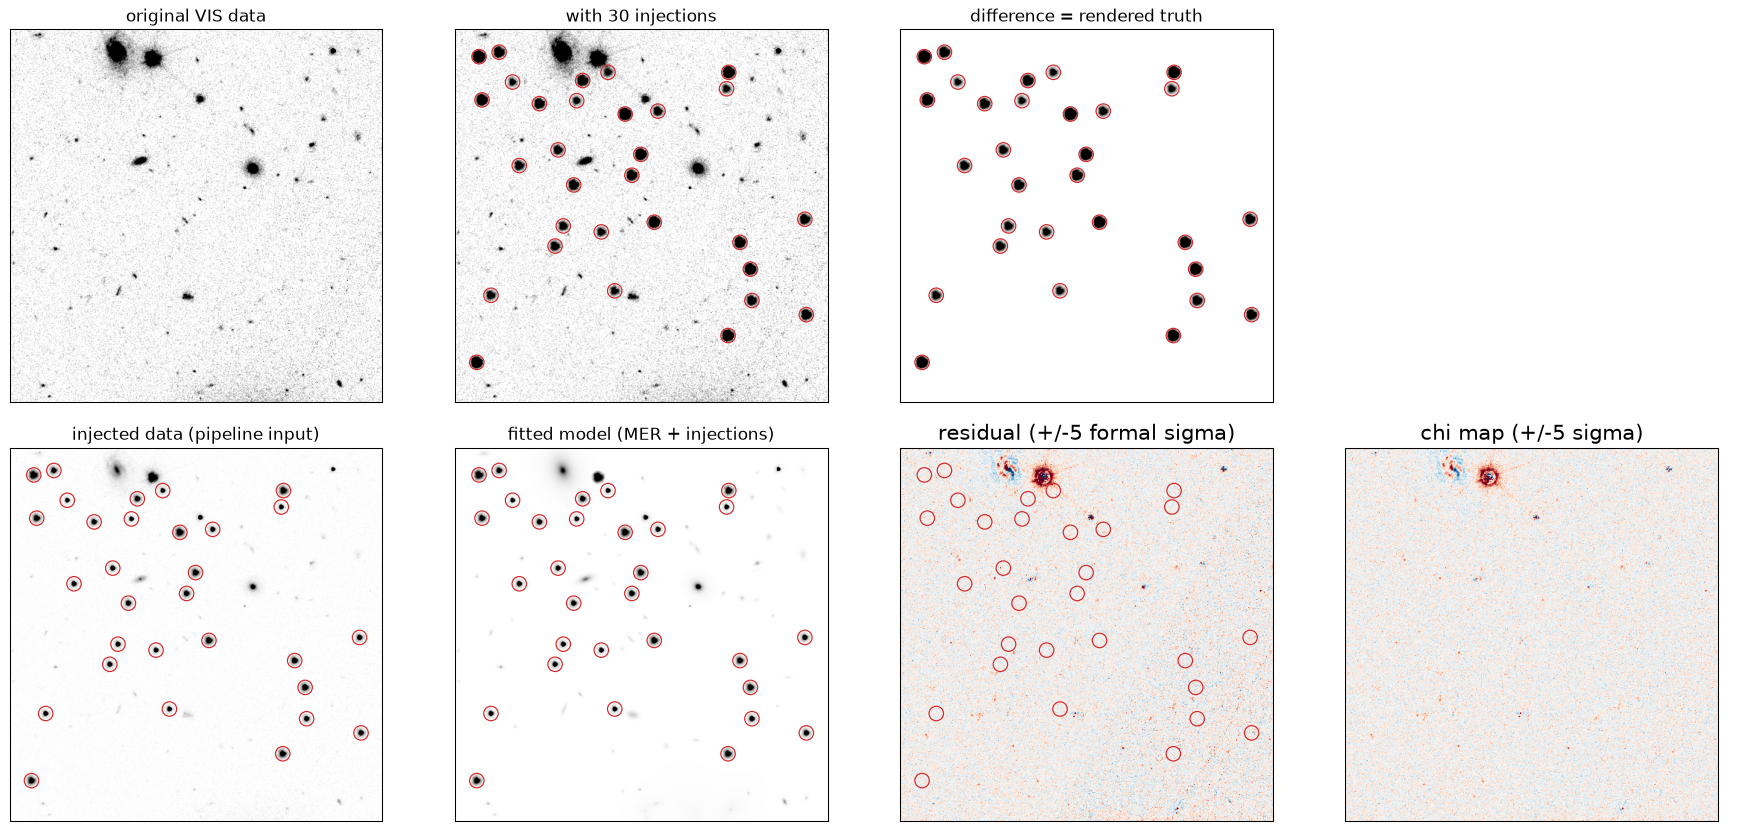

In [3]:
inj_cut = res_b.cutouts['VIS']                       # injected pixels
orig_cut = ep.fetch_cutout('VIS', TARGET_RA, TARGET_DEC,
                           CUTOUT_SIZE_ARCSEC, data_dir=DATA_DIR / 'cutouts')
injected_only = inj_cut.data - orig_cut.data          # the rendered truth

# Rebuild the same spatial-PSF scene used for fitting.
tim = ep.build_tractor_image(inj_cut,
    psf_data=res_b.psf_data['VIS'], pixel_mask=res_b.prior_pixel_mask)
res = ep.measure_residual(Tractor([tim], res_b.sources), tim)

px, py = inj_cut.wcs.world_to_pixel_values(
    np.asarray(truth_b['ra'], float), np.asarray(truth_b['dec'], float))

fig, axes = plt.subplots(2, 4, figsize=(19, 9))
vmax = float(np.nanpercentile(orig_cut.data, 99.5))
panels = [(axes[0, 0], orig_cut.data, 'original VIS data'),
          (axes[0, 1], inj_cut.data, 'with 30 injections'),
          (axes[0, 2], injected_only, 'difference = rendered truth')]
for ax, img, title in panels:
    ax.imshow(img, origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=13)
for ax in (axes[0, 1], axes[0, 2]):
    ax.scatter(px, py, s=120, facecolors='none', edgecolors='C3', lw=0.9)
axes[0, 3].axis('off')

vmax2 = float(np.nanpercentile(inj_cut.data, 99.5))
axes[1, 0].imshow(res['data'], origin='lower', cmap='gray_r',
                  vmin=0, vmax=vmax2)
axes[1, 0].set_title('injected data (pipeline input)', fontsize=13)
axes[1, 1].imshow(res['model'], origin='lower', cmap='gray_r',
                  vmin=0, vmax=vmax2)
axes[1, 1].set_title('fitted model (MER + injections)', fontsize=13)
ep.viz.show_residual(res['data'], res['model'], invvar=tim.getInvvar(),
                     ax=axes[1, 2], title='residual (+/-5 formal sigma)')
_, info_chi = ep.viz.show_chi_map(res['data'], res['model'],
                                  tim.getInvvar(),
                                  ax=axes[1, 3], title='chi map (+/-5 sigma)')
for ax in axes[1, :3]:
    ax.scatter(px, py, s=120, facecolors='none', edgecolors='C3', lw=0.9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

print(f"Whole-scene robust chi width: {info_chi['chi_mad']:.3f}")
print("The residual contains real sources too; use the recovery statistics")
print("below to assess the injected sources specifically.")


## 2. Faint sources: fluxes, uncertainties and completeness

Use five fixed random seeds, each with 40 sources, and report both each
run and the combined 200 injections. Forty-source pull widths can vary
substantially. Each run starts from the original image; the five batches
are not injected together. They sample the same field and are not five
independent sky/noise realizations.

The pull-width acceptance interval is 0.7–1.3. We also require
the combined median flux ratio to lie within 5% of unity in each band.
These are limited consistency checks, not evidence of exact error coverage.


In [4]:
FAINT = {"VIS": (0.04, 0.12), "Y": (0.4, 1.2),
         "J": (0.4, 1.2), "H": (0.45, 1.3)}
catalogs, truths, per_run = [], [], []
for seed in range(5):
    cat, truth = run_injection_recovery(
        data_dir=DATA_DIR, target_ra=TARGET_RA, target_dec=TARGET_DEC,
        cutout_size_arcsec=CUTOUT_SIZE_ARCSEC, bands=tuple(FAINT),
        n_inject=40, flux_range_ujy=FAINT, rng=seed,
        injection_psf_product="grid", psf_product="grid")
    for band in FAINT:
        s = summarize_recovery(cat, truth, band=band)
        per_run.append((seed, band, s['ratio_median'], s['pull_std']))
    # Retain injections only, and give each batch distinct IDs before stacking.
    cat = cat[np.isin(cat['object_id'], truth['object_id'])].copy()
    cat['object_id'] -= seed * 40
    truth['object_id'] -= seed * 40
    catalogs.append(cat)
    truths.append(truth)

Table(rows=per_run, names=('seed', 'band', 'median_ratio', 'pull_width')).pprint_all()
cat_f = vstack(catalogs, metadata_conflicts='silent')
truth_f = vstack(truths, metadata_conflicts='silent')
summaries = {band: summarize_recovery(cat_f, truth_f, band=band) for band in FAINT}
print(f"\n{'band':>5} {'fitted/total':>13} {'ratio':>7} {'pull':>7} {'S/N>5 fraction':>15}")
for band, s in summaries.items():
    print(f"{band:>5} {s['n_recovered']:>6}/{s['n_injected']:<6} "
          f"{s['ratio_median']:7.3f} {s['pull_std']:7.3f} {s['completeness']:15.3f}")


seed band    median_ratio        pull_width    
---- ---- ------------------ ------------------
   0  VIS 1.0039768945406715 1.1446243016850142
   0    Y 1.0201961318205854 0.5160124184474507
   0    J 0.9768901568964357 0.8276481232794263
   0    H 0.9928073968249874 0.8709848550114658
   1  VIS 0.9786239659303343 0.6392081353108039
   1    Y 1.0149961133067633  0.789306697450178
   1    J 0.9787162546242507 0.9039337922229855
   1    H 1.0010824740422994  0.899839565407392
   2  VIS 1.0204159688553245 0.8630394376866106
   2    Y 0.9915762695025159 0.8016974165365678
   2    J  1.019671772857056 0.6812292892239574
   2    H 0.9586593451078748 1.4074947648924676
   3  VIS 1.0009933610195878 0.6563372393275543
   3    Y 1.0243419760833752 0.7852141369865583
   3    J  0.994291794411434  0.867209299695358
   3    H 1.0266612166212798 1.2138906875052324
   4  VIS 0.9965088184954904 0.5875925884418515
   4    Y 0.9877206180571065 0.9039984913409167
   4    J 1.0091280694406457 1.226434064

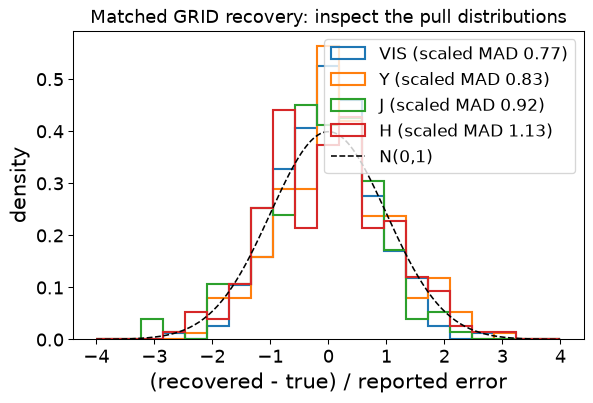

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

x = np.linspace(-4, 4, 200)
for band in ("VIS", "Y", "J", "H"):
    ax.hist(summaries[band]['pull'], bins=np.linspace(-4, 4, 22),
            density=True, histtype='step', lw=1.6,
            label=f"{band} (scaled MAD {summaries[band]['pull_std']:.2f})")
ax.plot(x, np.exp(-x**2 / 2) / np.sqrt(2 * np.pi), 'k--', lw=1.2,
        label='N(0,1)')
ax.set_xlabel('(recovered - true) / reported error')
ax.set_ylabel('density')
ax.set_title('Matched GRID recovery: inspect the pull distributions', fontsize=14)
ax.legend(fontsize=13)
plt.tight_layout()
plt.show()


## 3. Inspect dependence on true flux

The combined VIS results are also binned by injected flux. Selection and
background structure can affect these statistics; inspect the counts and
ratios rather than assuming a trend has a single cause.


In [6]:
print("VIS, faint run:")
summaries['VIS']['bins'].pprint_all()
print(f"\ncompleteness (flux_quality and S/N > 5): "
      f"{summaries['VIS']['completeness']:.2f}")

VIS, faint run:
    flux_lo_ujy          flux_hi_ujy       n     ratio_median         ratio_mad           pull_std     
-------------------- -------------------- --- ------------------ ------------------- ------------------
0.040010447808938844 0.052652342409028954  39 0.9877514622890342 0.10071674739386381 0.6857691925019794
0.052652342409028954   0.0692886311694384  50 1.0032622213653244 0.08470991650811106 0.6870314041364646
  0.0692886311694384  0.09118140218793373  55  1.003806040366684 0.06736272335137958 0.7592064427064158
 0.09118140218793373  0.11999151902173619  56 0.9916050110454049 0.05942574258326137 0.8746717521098875

completeness (flux_quality and S/N > 5): 0.98


## 4. Acceptance checks

The plots and all band statistics appear before these assertions. A failed
check remains a failure; do not adjust the error bars or the limits just to
make this cell pass. A passing combined sample can still contain individual
runs or flux bins that deserve investigation.


In [7]:
checks = {"bright VIS flux scale": abs(s_b['ratio_median'] - 1) < 0.05}
for band, s in summaries.items():
    checks[f"{band} faint flux scale"] = abs(s['ratio_median'] - 1) < 0.05
    checks[f"{band} faint pull width"] = 0.7 < s['pull_std'] < 1.3
for label, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}: {label}")
assert all(checks.values()), "Investigate the failed recovery checks listed above."


PASS: bright VIS flux scale
PASS: VIS faint flux scale
PASS: VIS faint pull width
PASS: Y faint flux scale
PASS: Y faint pull width
PASS: J faint flux scale
PASS: J faint pull width
PASS: H faint flux scale
PASS: H faint pull width


## Scope

Return to [Notebook 01](../01_multiband_forced_photometry.ipynb).

These tests use injected point sources, supplied positions, one field and
a matching PSF prescription. They do not validate the real PSF, galaxy
profiles, detection completeness, close-blend uncertainty, or source photon
noise. GRID-injection/CATALOG-recovery is a separate PSF-mismatch experiment;
it should not be confused with this matching-PSF consistency test.
